# Ripple Testing

In [ ]:


# Loading/Import related packages
import sys
import os

#Usual suspects
import pandas as pd
import numpy as np
import json
import pickle as pkl
import matplotlib.pyplot as plt

#Extras for plotting
from matplotlib.patches import Patch

#Extra for typing
from collections import defaultdict

#os.chdir(r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\Ripple")
os.chdir(r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\PatientPlatform")


In [ ]:
REPO_DIR  = os.path.abspath(os.getcwd())
# INPUT_DIR = os.path.join(REPO_DIR, 'data')
# OUTPUT_DIR = os.path.join(REPO_DIR, 'results')
INPUT_DIR = os.path.join(REPO_DIR, 'output')
OUTPUT_DIR = os.path.join(REPO_DIR, 'results')

#from src.muniverse.algorithms.core import bandpass_signals, notch_signals
from bend.ripple_analysis_functions import get_task_data, remove_spikes, calc_PSD, plot_emg_with_movement, analyze_movement_snr, bandpass_signals, notch_signals

sys.path.insert(0, os.path.abspath("bend")) 
from bend.src.utils.select_windows import select_windows
from bend.src.utils.review_channels import review_channels

good_mask_path = "demo_good_mask.npy"
mask_path = "demo_mask.npy"
exclude_path = "demo_exclude.npy"

In [3]:
# This task used 3 tasks, each with 8 repitions
n_reps = 8
n_tasks = 3
movement_names = ['fist', 'fast_tripod', 'fast_finger_ext']

samp_freq = 2000
n_channels = 32

In [ ]:



#combined_data_1_path = os.path.join(INPUT_DIR, 'emg_recording_gian_testday1_20260929_102639_divided')
# s1_folder = os.path.join(INPUT_DIR, 'emg_recording_gian_testday1_20260929_102639_divided')
# s2_folder = os.path.join(INPUT_DIR, 'emg_recording_gian_testday2_20260930_111953_divided')

s1_folder = os.path.join(INPUT_DIR, 'emg_recording_Liz_session_001_20260930_144300_divided')


# result_pandas = pd.read_pickle(s1_folder)
# print(result_pandas.keys())
# print(result_pandas['trial_metadata']['items'])


In [5]:
file_path =  os.path.join(REPO_DIR, "output\emg_recording_Liz_session_001_20260930_144300_divided\move_001.pkl")

result_pandas = pd.read_pickle(file_path)
print("Loaded data from:", file_path)
print(result_pandas.keys())
print(result_pandas['data'].shape)

Loaded data from: C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\PatientPlatform\output\emg_recording_Liz_session_001_20260930_144300_divided\move_001.pkl
dict_keys(['data', 'srate', 'phase', 'phase_occurrence', 'start_s', 'end_s', 'n_samples', 'duration_s', 'filtered', 'stream_type', 'trial_metadata'])
(32, 9340)


### Signal

##### Session 1

Note that fist and ft are super noisy. Using ffe for decomp.

In [ ]:
s1_full = get_task_data(s1_folder, 8, movement_names, samp_freq, win = None)

s1_fist_dict = s1_full['fist']
s1_fist_emg = s1_fist_dict['movement']['emg_combined']
s1_fist_combined = s1_fist_dict['m_r_combined']

s1_ft_dict = s1_full['fast_tripod']
s1_ffe_dict = s1_full['fast_finger_ext']
s1_ffe_emg = s1_ffe_dict['movement']['emg_combined']
s1_ffe_all_emg = s1_ffe_dict['m_r_combined']['emg_combined']

s1_ffe_rest_emg = s1_ffe_dict['rest']['emg_combined']



# isolating just middle 4 seconds, should be isometrical hold only. No start of movement.
"""
Maybe need to change window to cut off first N seconds because that is when the movement is initiated.
Isometrical hold for entire period, participant releases movement after movement duration period (ie first N seconds of rest)
"""
s1_iso4 = get_task_data(s1_folder, 8, movement_names, samp_freq, win = 4)

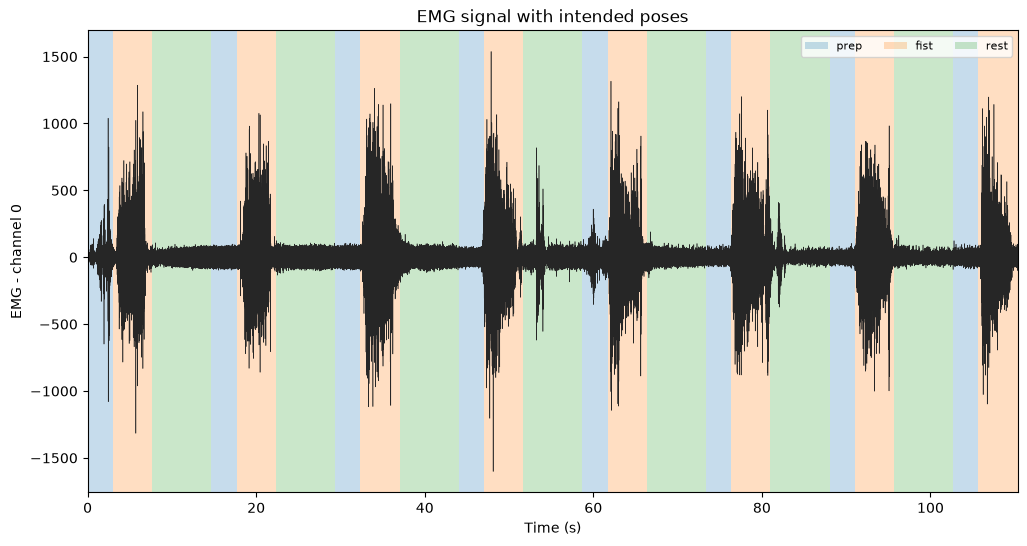

In [ ]:
plot_emg_with_movement(s1_fist_dict['m_r_combined']['emg_combined'], 
                       s1_fist_dict['m_r_combined']['poses'], 
                       s1_fist_dict['m_r_combined']['duration'], 
                       fs=samp_freq)
plt.show()



##### Session 2

In [ ]:
s2_full = get_task_data(s2_folder, 8, movement_names, samp_freq, win = None)
s2_fist = s2_full['fist']
s2_ft = s2_full['fast_tripod']
s2_ffe = s2_full['fast_finger_ext']

s2_fist_rest = s2_fist['rest']

s2_dict = [s2_fist['m_r_combined'], s2_ft['m_r_combined'], s2_ffe['m_r_combined']]


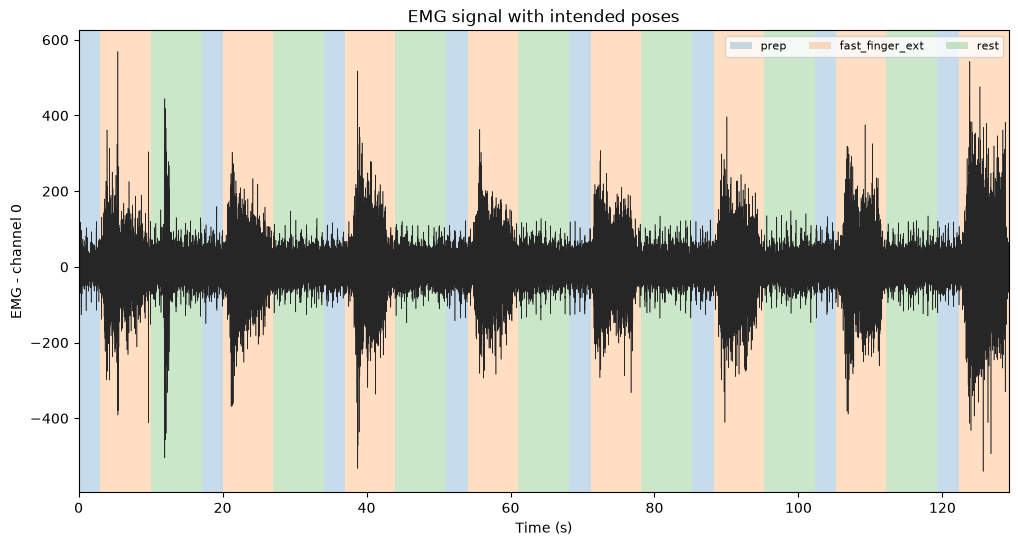

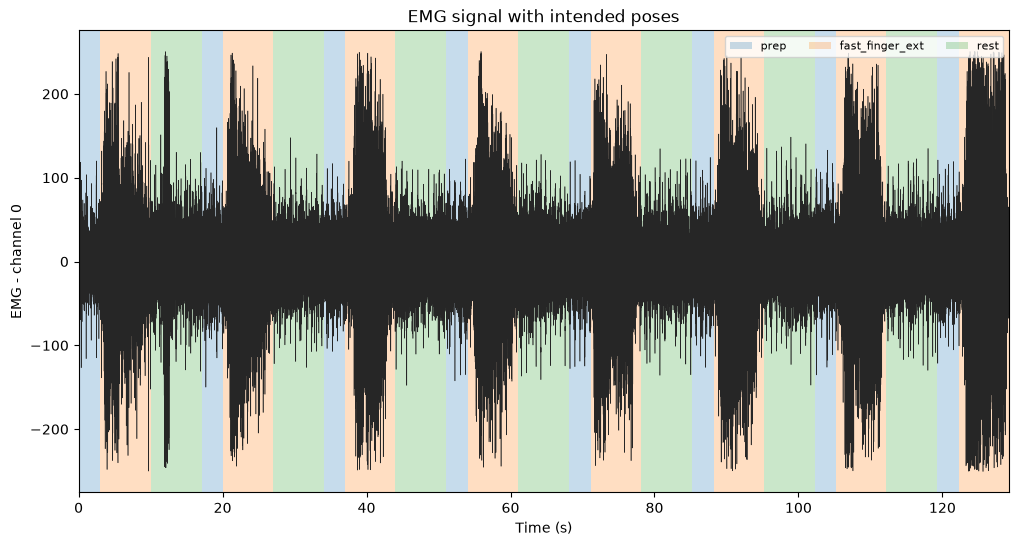

In [ ]:
plot_emg_with_movement(s2_ffe['m_r_combined']['emg_combined'], 
                       s2_ffe['m_r_combined']['poses'], 
                       s2_ffe['m_r_combined']['duration'], 
                       fs=samp_freq)
plt.show()

s2_ffe_clean_dict = s2_ffe.copy()
s2_ffe_clean_dict, s1_ffe_spike_mask = remove_spikes(s2_ffe_clean_dict['m_r_combined'], threshold_std=5)

plot_emg_with_movement(s2_ffe_clean_dict['emg_combined'], 
                       s2_ffe_clean_dict['poses'], 
                       s2_ffe_clean_dict['duration'], 
                       fs=samp_freq)
plt.show()

### Preprocessing

##### Bandpass + Notch Filters

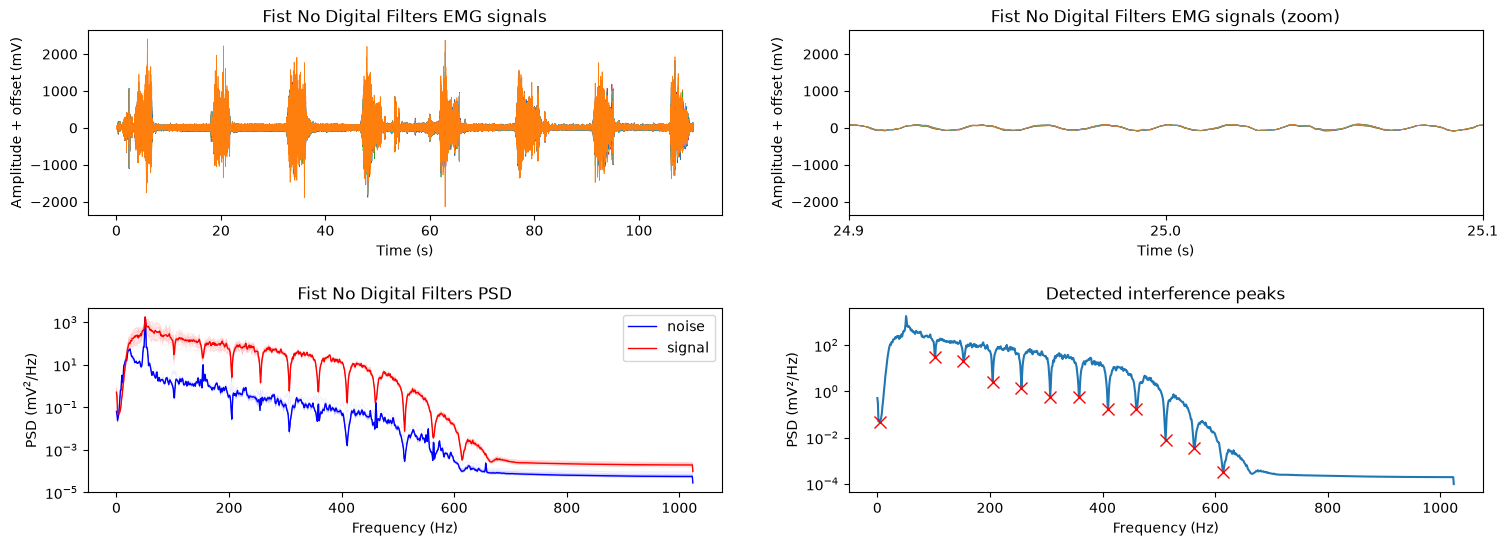

[98. 51. 52. 51. 51. 52. 51. 50. 52. 51. 51.]


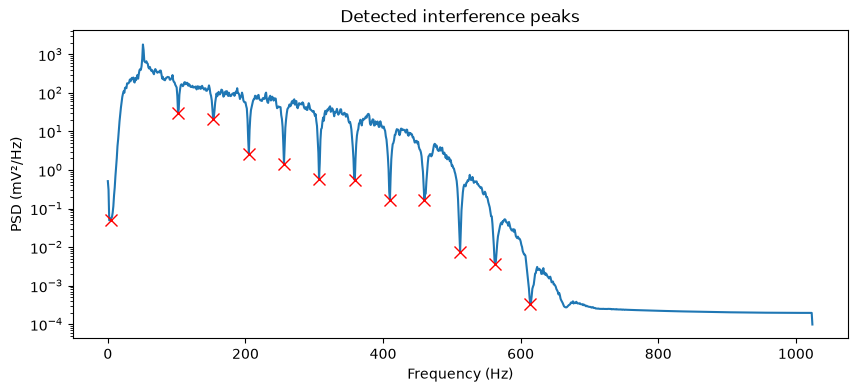

In [ ]:

from scipy.signal import find_peaks

sequence_psd = analyze_movement_snr(s1_fist_combined, samp_freq, nsamples = len(s1_fist_combined['emg_combined'][0]),
                                     save_path="results/s1_fist.png",
                                     title_str = "Fist No Digital Filters ")

p_med = np.median(sequence_psd['Ps'], axis = 0)


troughs, props = find_peaks(-np.log10(p_med), prominence=0.5)
trough_freqs = sequence_psd['fsig'][troughs]

diffs_t = np.diff(np.sort(trough_freqs))
print(diffs_t)

plt.figure(figsize=(10,4))
plt.semilogy(sequence_psd['fsig'], p_med)
plt.semilogy(trough_freqs, p_med[troughs], "rx", markersize=8)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (mV²/Hz)")
plt.title("Detected interference peaks")
plt.show()



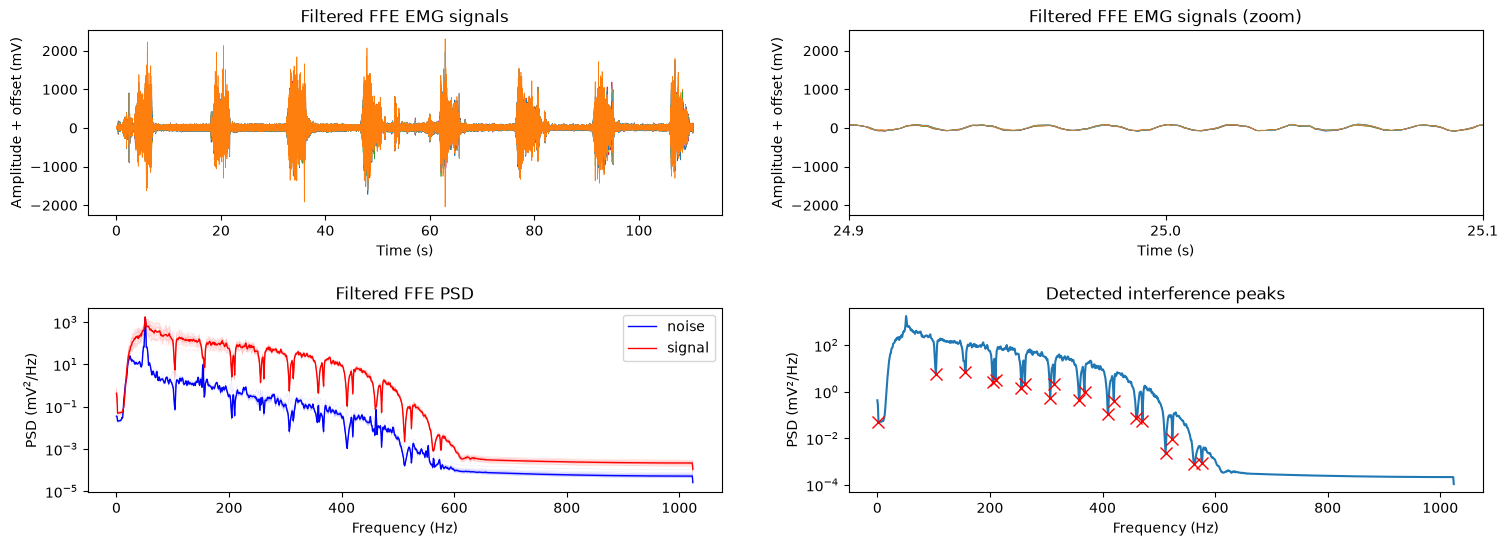

[102.  52.  49.   5.  46.   6.  45.   7.  45.   9.  42.  10.  40.  11.
  41.  12.  39.  13.]


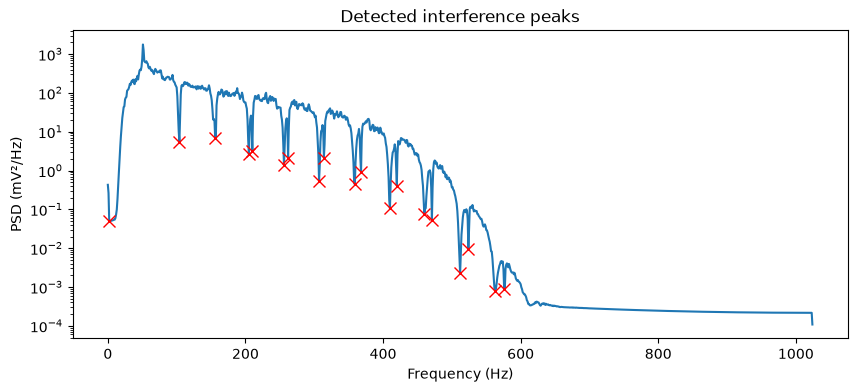

In [ ]:

#Apply a notch filter
sig = s1_fist_combined.copy()
for trough in trough_freqs:
    sig = notch_signals(
        emg_dict = sig, 
        fsamp=2000, 
        nfreq=trough, 
        dfreq=1,
        order=2,
        n_harmonics = 1
    )

# Apply a bandpass filter
sig = bandpass_signals(
    emg_dict=sig,
    fsamp=samp_freq,
    high_pass=20,
    low_pass=500,
    order=2
)

sequence_psd_digfilt = analyze_movement_snr(sig, samp_freq, nsamples = len(sig['emg_combined'][0]),
                                     save_path="results/s1_fist_digfilt_harm10.png",
                                     title_str = "Filtered FFE ")
p_med = np.median(sequence_psd_digfilt['Ps'], axis = 0)

troughs_filt, props = find_peaks(-np.log10(p_med), prominence=0.5)
trough_freqs = sequence_psd_digfilt['fsig'][troughs_filt]

diffs_t = np.diff(np.sort(trough_freqs))
print(diffs_t)

plt.figure(figsize=(10,4))
plt.semilogy(sequence_psd_digfilt['fsig'], p_med)
plt.semilogy(trough_freqs, p_med[troughs_filt], "rx", markersize=8)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (mV²/Hz)")
plt.title("Detected interference peaks")
plt.show()



#### Remove Spikes

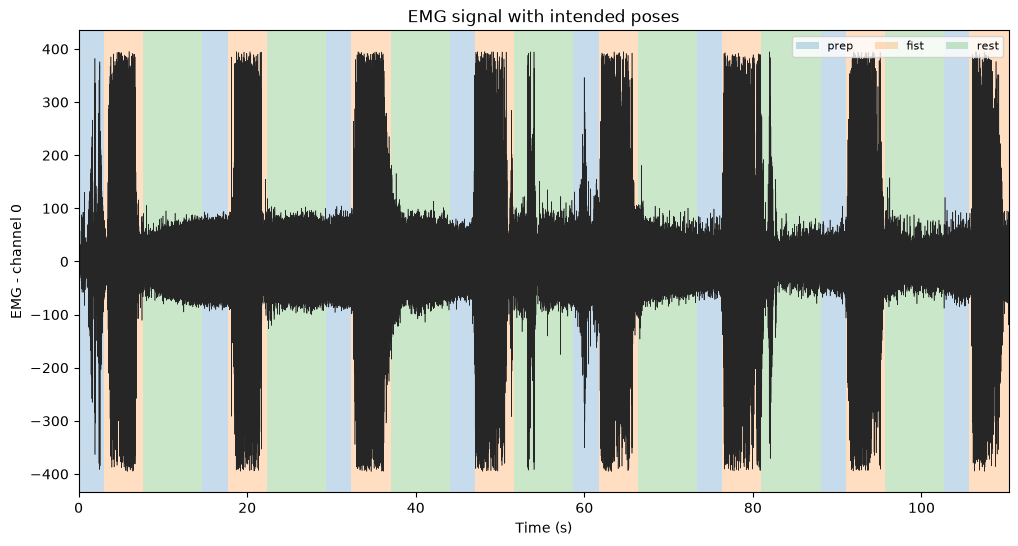

In [ ]:
s1_fist_clean, s1_fist_spike_mask = remove_spikes(sig, threshold_std=3)

plot_emg_with_movement(s1_fist_clean['emg_combined'], 
                       s1_fist_clean['poses'], 
                       s1_fist_clean['duration'], 
                       fs=samp_freq)
plt.show()

#### Review Channels

In [ ]:
review_channels(s1_ffe_clean_dict['m_r_combined']['emg_combined'], 
                good_mask_path, fs=samp_freq, label="demo")

KeyError: 'm_r_combined'

In [ ]:
# Load the baseline configuration
with open(os.path.join(REPO_DIR, 'src', 'configs', 'cbss.json')) as f:
    cbss_config = json.load(f)['Config']

# The JSON stores disabled options as the string "None", turn them back into real None
cbss_config = {k: (None if v == "None" else v) for k, v in cbss_config.items()}

# Fewer iterations than the config asks for, again just to keep the notebook quick
cbss_config['opt_function_exp'] = 2

print(json.dumps(cbss_config, indent=2))

{
  "start_time": 0,
  "end_time": -1,
  "sampling_frequency": 2048,
  "bandpass": null,
  "bandpass_order": 2,
  "notch_frequency": 50,
  "notch_n_harmonics": 3,
  "notch_order": 2,
  "notch_width": 1,
  "ext_fact": 16,
  "whitening_method": "ZCA",
  "whitening_reg": "auto",
  "ica_n_iter": 100,
  "opt_initalization": "random",
  "opt_function_exp": 2,
  "opt_max_iter": 100,
  "opt_tol": 0.0001,
  "source_deflation": "gram-schmidt",
  "peel_off": true,
  "fr_peeloff": true,
  "cluster_method": "kmeans",
  "random_seed": 1909,
  "refinement_loop": true,
  "sil_th": 0.85,
  "cov_th": 0.35,
  "verbose_mode": true
}


In [ ]:
from src.muniverse.algorithms.cbss import CBSS

decomposer = CBSS(**cbss_config)

sources_cbss, spikes_cbss, sil_cbss, filters_cbss, Z_cbss, centroids_cbss = decomposer.decompose(
    sig_remove_spikes['emg_combined'], fsamp=samp_freq
)

# all rejected, very high CoVs, 1.507, perhaps because of too much noise??

[INFO] Extending signals by factor 16...

STARTING CBSS DECOMPOSITION
Max iterations: 100, Silhouette threshold: 0.850, CoV threshold: 0.350

Refinement loop for source 0 (initial Sil: 0.942, CoV: 6.717, Spikes: 410)
FR peel-off enabled
Refinement loop for source 1 (initial Sil: 0.979, CoV: 4.112, Spikes: 275)
FR peel-off enabled
Refinement loop for source 2 (initial Sil: 0.977, CoV: 4.142, Spikes: 279)
FR peel-off enabled
Refinement loop for source 3 (initial Sil: 0.946, CoV: 5.042, Spikes: 399)
FR peel-off enabled
Refinement loop for source 4 (initial Sil: 0.931, CoV: 6.922, Spikes: 435)
FR peel-off enabled
Refinement loop for source 5 (initial Sil: 0.971, CoV: 3.571, Spikes: 281)
FR peel-off enabled
Refinement loop for source 6 (initial Sil: 0.980, CoV: 8.710, Spikes: 277)
FR peel-off enabled
Refinement loop for source 7 (initial Sil: 0.979, CoV: 4.181, Spikes: 275)
FR peel-off enabled
Refinement loop for source 8 (initial Sil: 0.944, CoV: 5.143, Spikes: 417)
FR peel-off enabled
Ref